**Supervised Learning**

In [ ]:
#importing the libraries needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import *
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
!pip install lets-plot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 5.7 MB/s eta 0:00:00


In [ ]:
#Comparring the outputs
datas = pd.read_csv("cancer_CleanData.csv")
print(datas.isnull().sum())


id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [ ]:
missing_values = ["n/a","na","--"] #Handling missing values
#Reading the csv file
data = pd.read_csv("cancer_NoiseData.csv", na_values=missing_values)

#Finding the sum of missing values in the dataset
print(data.isnull().sum())

id                         0
diagnosis                  0
radius_mean                1
texture_mean               0
perimeter_mean             0
area_mean                  1
smoothness_mean            0
compactness_mean           1
concavity_mean             1
concave points_mean        1
symmetry_mean              1
fractal_dimension_mean     1
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    2
smoothness_se              0
compactness_se             0
concavity_se               1
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [ ]:
#Filling missing values in the radius_mean column
median_RadiusMean = data['radius_mean'].median()
data['radius_mean'] = data['radius_mean'].fillna(median_RadiusMean)

#Filling missing values in the area_mean column
median_AreaMean = data['area_mean'].median()
data['area_mean'] = data['area_mean'].fillna(median_AreaMean)

#Filling missing values in the compactness_mean column
median_CompactnessMean = data['compactness_mean'].median()
data['compactness_mean'] = data['compactness_mean'].fillna(median_CompactnessMean)

#Filling missing values in the concavity_mean column
median_ConcavityMean = data['concavity_mean'].median()
data['concavity_mean'] = data['concavity_mean'].fillna(median_ConcavityMean)

#Filling missing values in the concave points_mean  column
median_ConPointsMean = data['concave points_mean'].median()
data['concave points_mean'] = data['concave points_mean'].fillna(median_ConPointsMean)

#Filling missing values in the symmetry_mean column
median_SymmetryMean = data['symmetry_mean'].median()
data['symmetry_mean'] = data['symmetry_mean'].fillna(median_SymmetryMean)

#Filling missing values in the fractal_dimension_median  column
median_FractDimensionMean = data['fractal_dimension_mean'].median()
data['fractal_dimension_mean'] = data['fractal_dimension_mean'].fillna(median_FractDimensionMean)

#Filling missing values in the area_se column
median_AreaSe = data['area_se'].median()
data['area_se'] = data['area_se'].fillna(median_AreaSe)

#Filling missing values in the concavity_se column
median_ConcavitySe = data['concavity_se'].median()
data['concavity_se'] = data['concavity_se'].fillna(median_ConcavitySe)
print(data.isnull().sum())

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [ ]:
# Encode for the ML
data['diagnosis_numeric'] = data['diagnosis'].map({'B': 0, 'M': 1})
#Features selsection
features = [
    'radius_mean', 'texture_mean',
    'concavity_mean', 'concave points_mean',
    'radius_worst', 'texture_worst',
    'concave points_worst', 'compactness_worst'
]




**Exploratory Data Analysis**

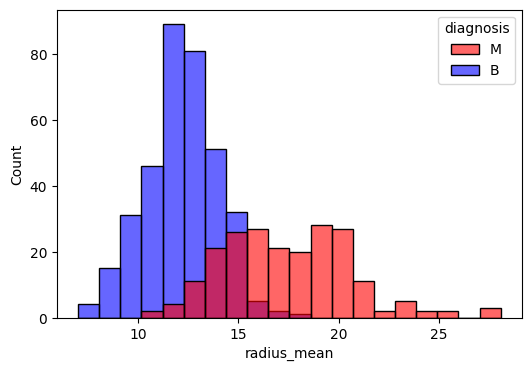

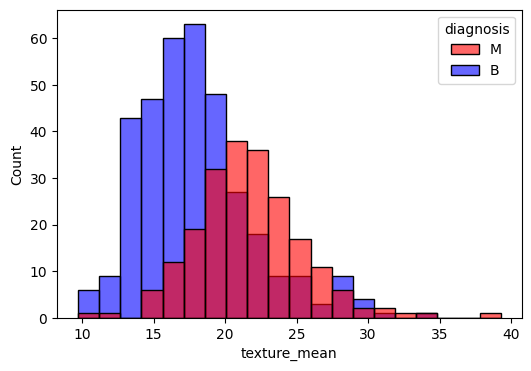

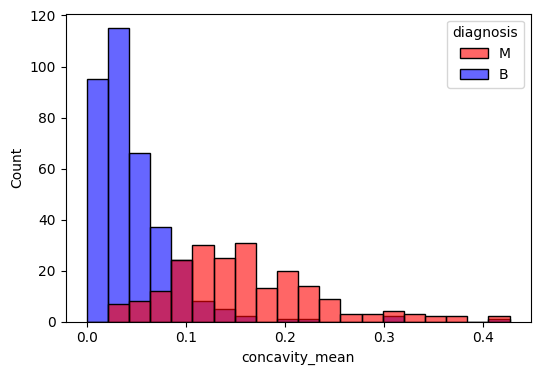

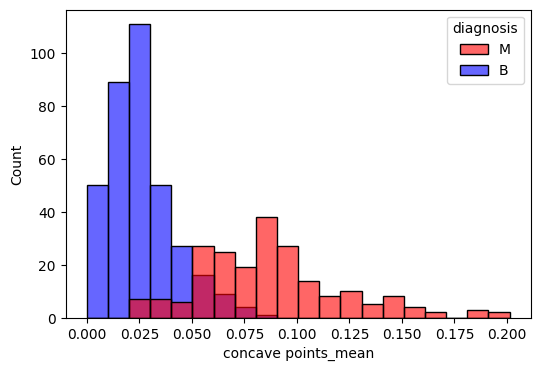

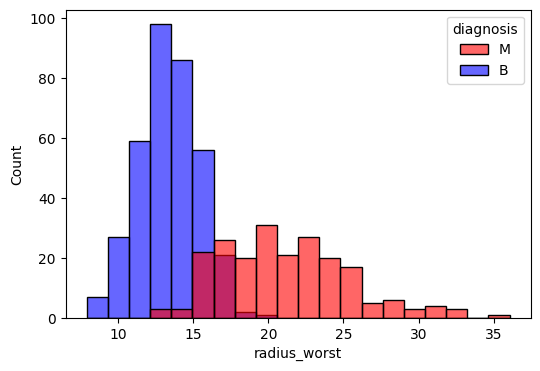

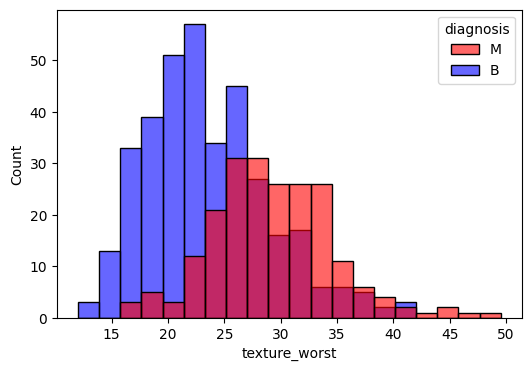

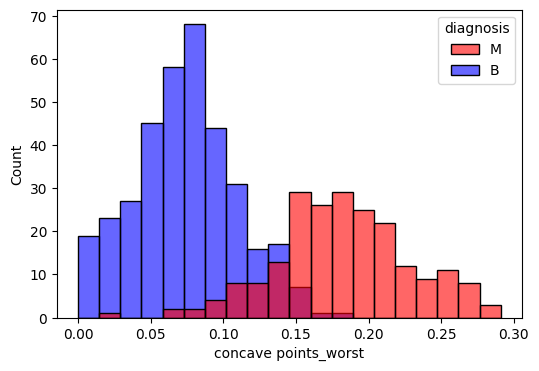

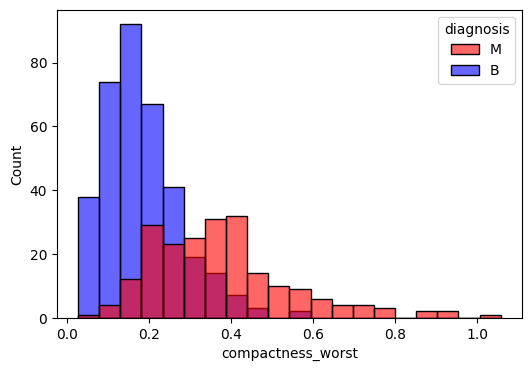

In [ ]:

# Histograms
for col in features:
    plt.figure(figsize=(6,4))
    sns.histplot(
        data=data,
        x=col,
        hue='diagnosis',
        bins=20,
        palette={'B':'blue','M':'red'},
        alpha=0.6
    )
plt.show()


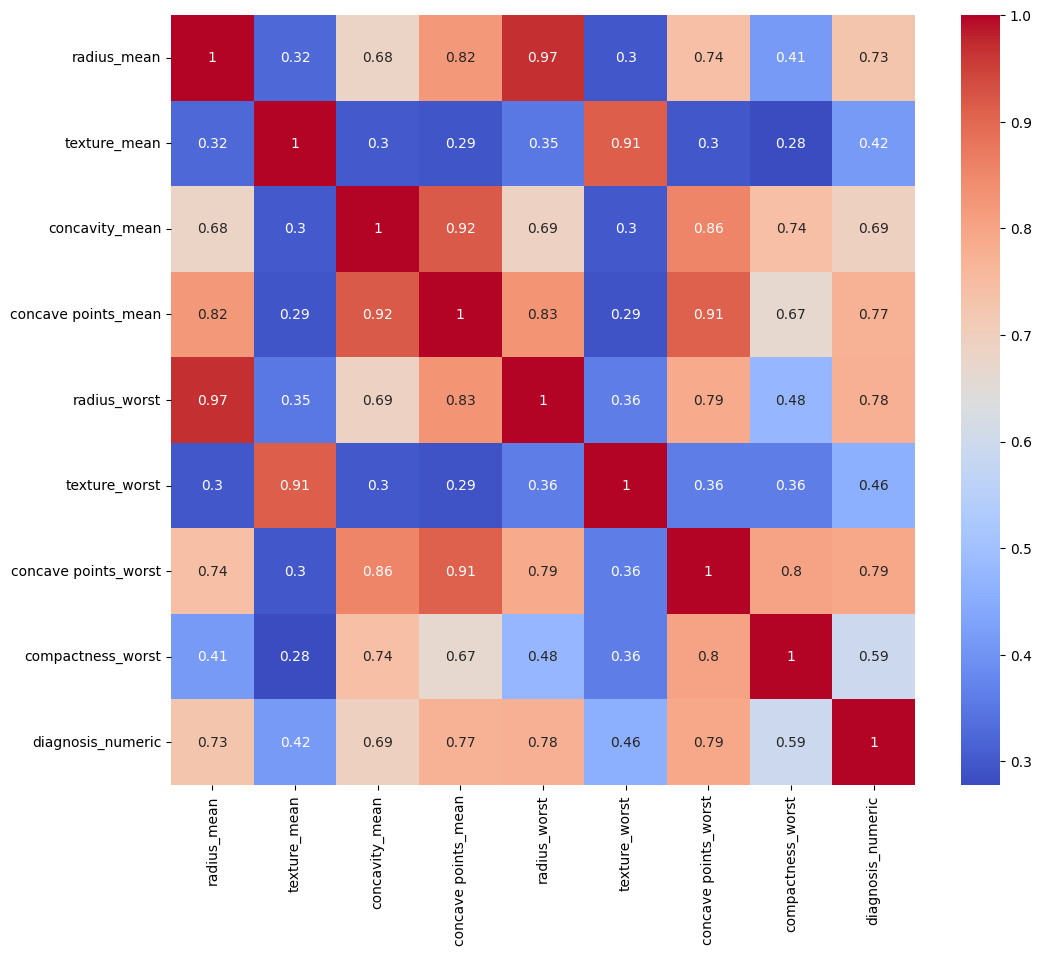

In [ ]:
# Heatmap
plt.figure(figsize=(12,10))
corr = data[features + ['diagnosis_numeric']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

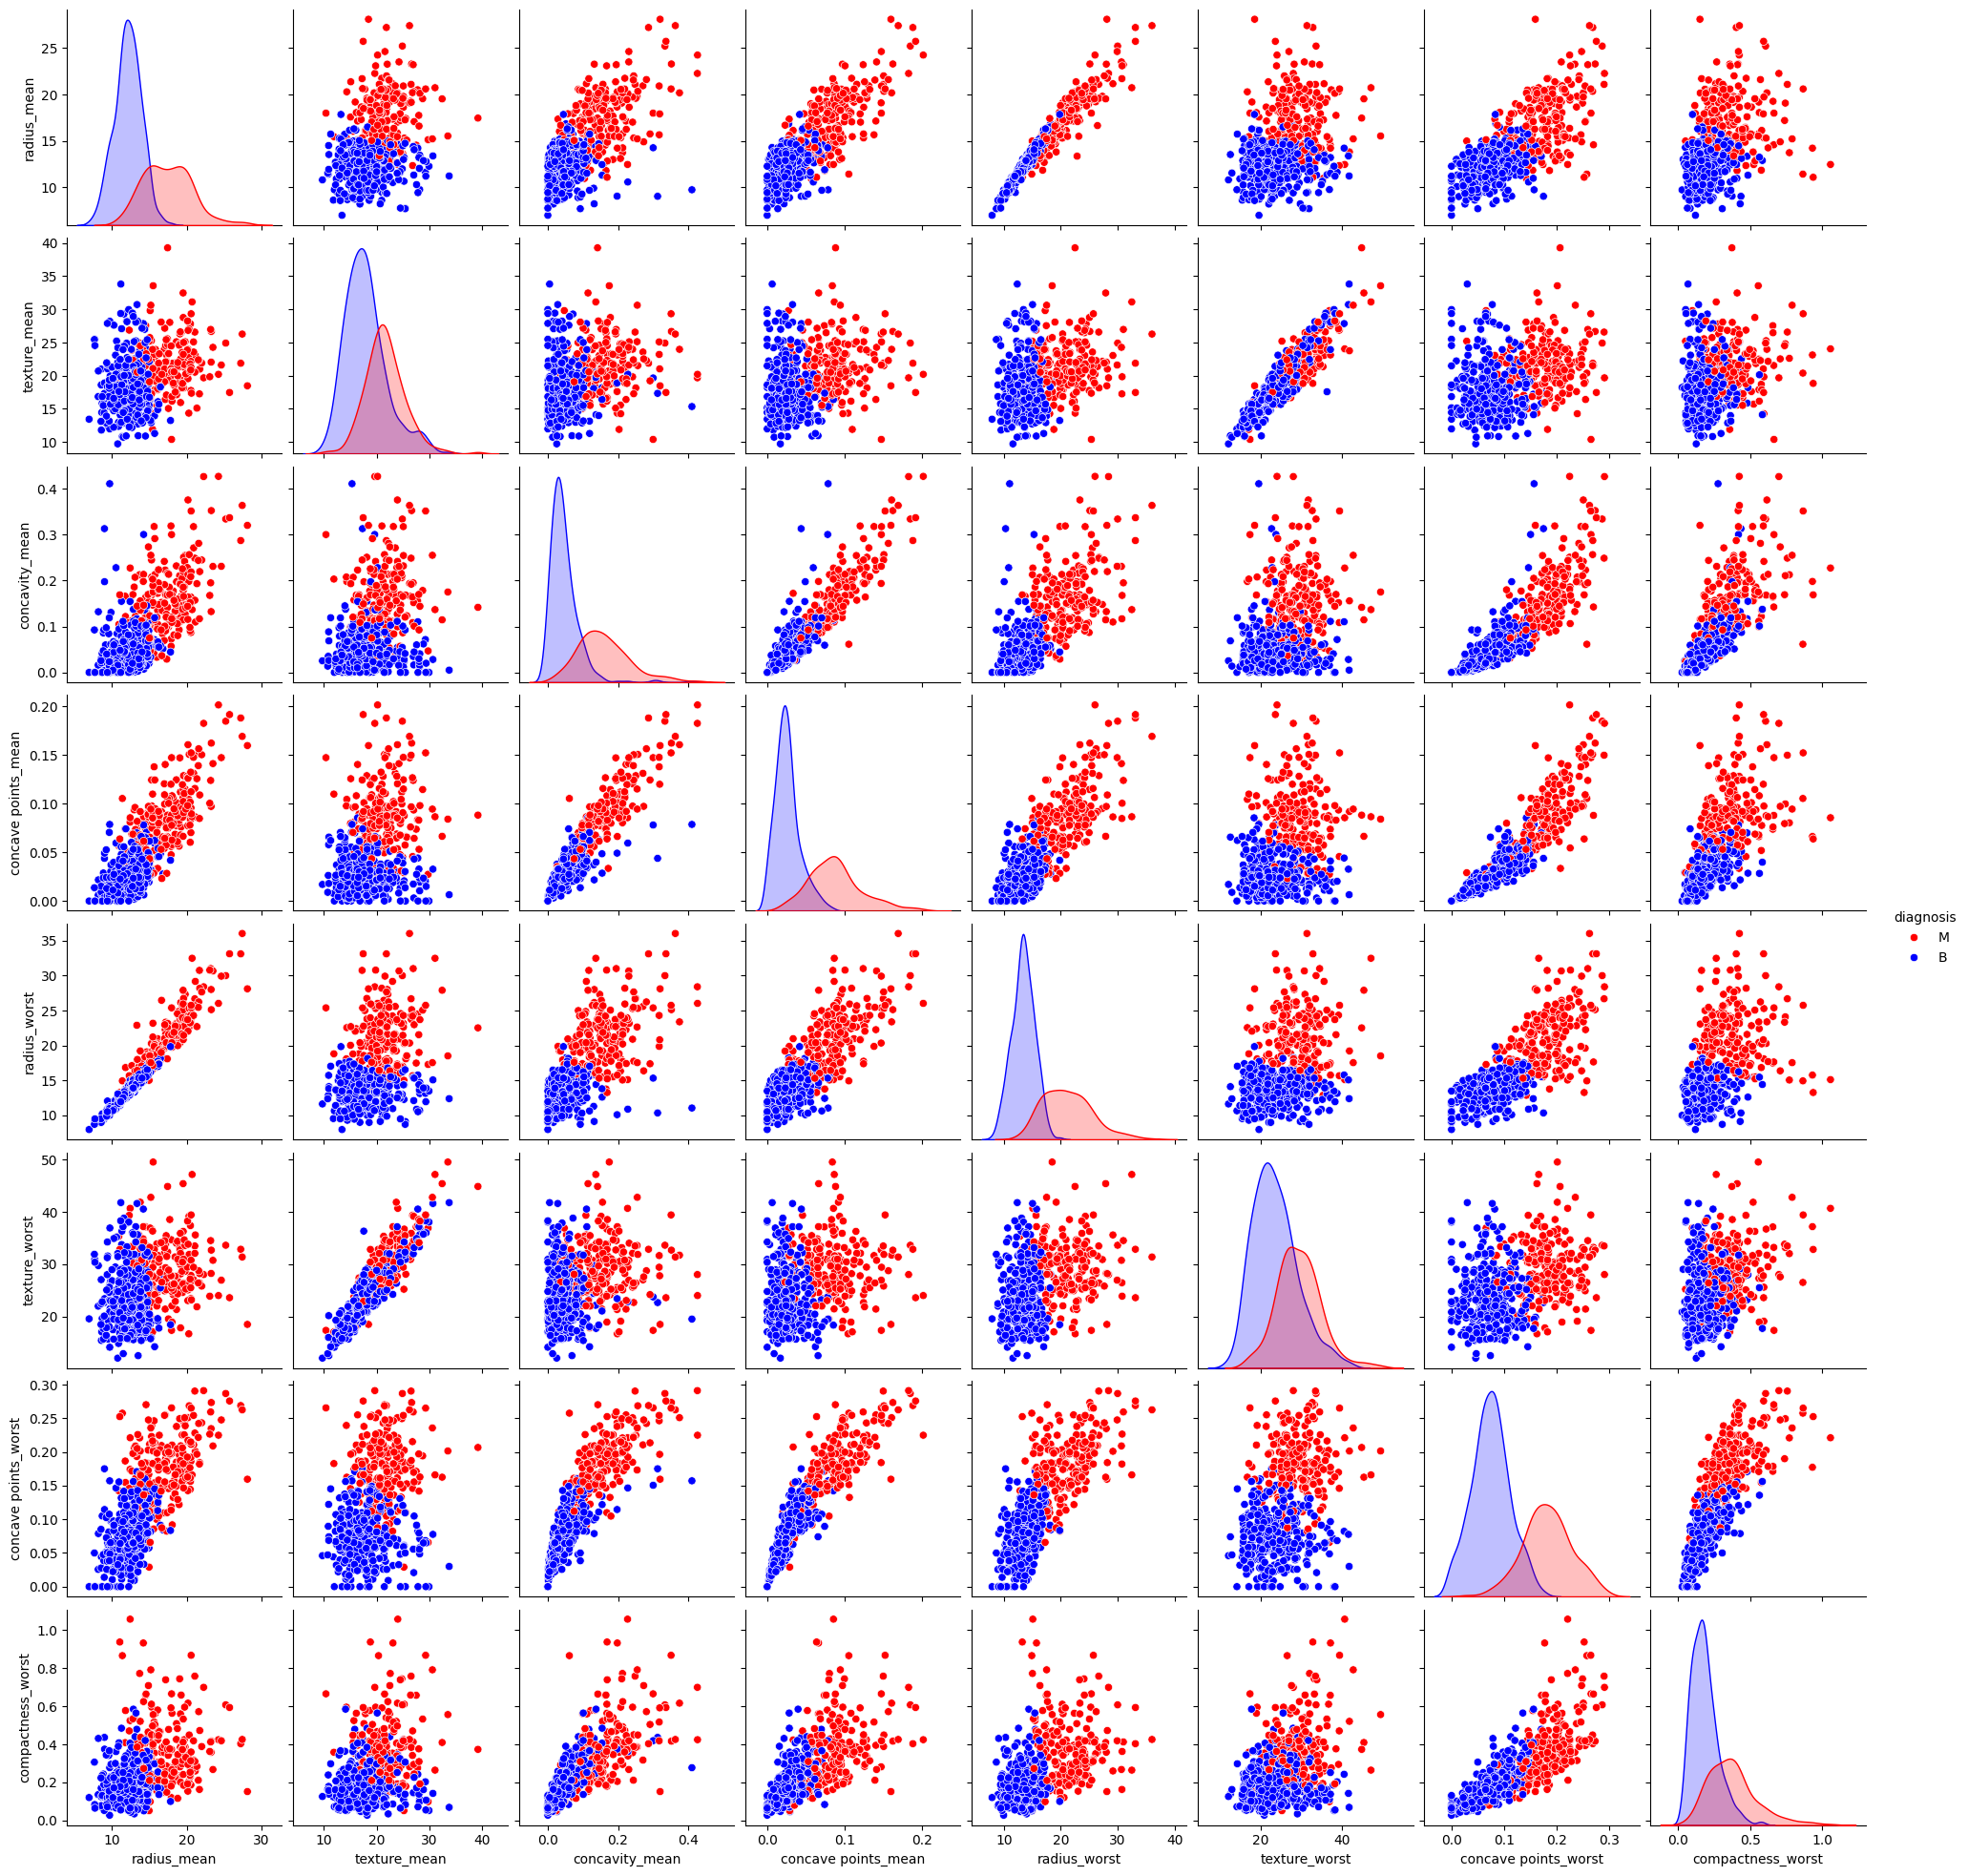

In [ ]:
# Pairplot
pairplot_features = features + ['diagnosis']

sns.pairplot(
    data=data[pairplot_features],
    hue='diagnosis',
    palette={'B':'blue','M':'red'}
)
plt.show()


**Model Development and Evaluation**

In [ ]:
#Output without SMOTE
# Prepare data
X = data[features]
y = data['diagnosis_numeric']

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scale
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

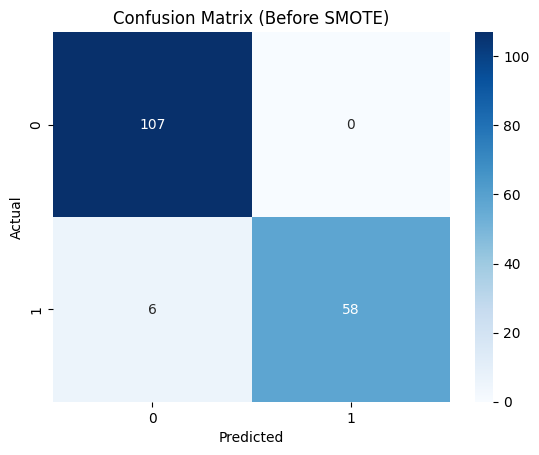

In [ ]:
# Training the Model

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Confudion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Before SMOTE)")
plt.show()

In [ ]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

[[107   0]
 [  6  58]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       107
           1       1.00      0.91      0.95        64

    accuracy                           0.96       171
   macro avg       0.97      0.95      0.96       171
weighted avg       0.97      0.96      0.96       171

Accuracy: 0.9649122807017544


**Adding SMOTE**

In [ ]:

#Preparing data for ML
X = data[features]
y = data['diagnosis_numeric']


#Train and test data split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


# Applying SMOTE technique on training data only

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Scaling the dataset

scaler = MinMaxScaler()

X_train_sm = scaler.fit_transform(X_train_sm)
X_test = scaler.transform(X_test)

print("\nBefore SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_sm).value_counts())





Before SMOTE:
diagnosis_numeric
0    250
1    148
Name: count, dtype: int64

After SMOTE:
diagnosis_numeric
1    250
0    250
Name: count, dtype: int64


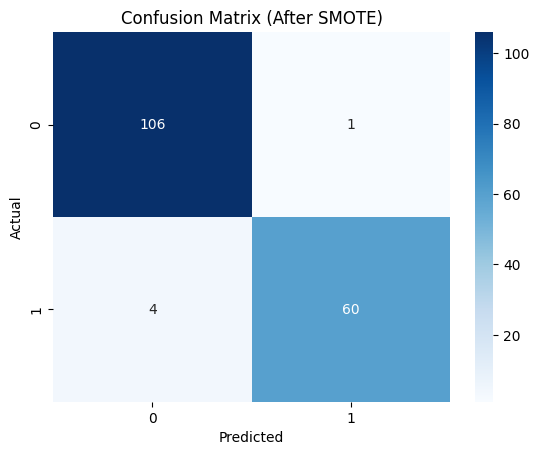

In [ ]:

# Training the Model

model = RandomForestClassifier(random_state=42)
model.fit(X_train_sm, y_train_sm)

# Predictions
y_pred_sm = model.predict(X_test)

# Confudion Matrix
cm = confusion_matrix(y_test, y_pred_sm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (After SMOTE)")
plt.show()



**Chekcking for data leakage**

In [ ]:



#Validating no data leakage
model = RandomForestClassifier(random_state=42)
scores = cross_val_score(model, X_train_sm, y_train_sm, cv=5)

print("Cross-validation scores:", scores)
print("Mean CV score:", scores.mean())



Cross-validation scores: [0.98 0.98 0.95 0.97 0.96]
Mean CV score: 0.968


In [ ]:
#Classification Report

print("\nClassification Report:")
print(classification_report(y_test, y_pred_sm))
print("Accuracy:", accuracy_score(y_test, y_pred_sm))



Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       107
           1       0.98      0.94      0.96        64

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171

Accuracy: 0.9707602339181286


:

In [ ]:
#Comparing the model's perfomance with SMOTE and without SMOTE
print("WITHOUT SMOTE")
print(classification_report(y_test, y_pred))

print("\nWITH SMOTE")
print(classification_report(y_test, y_pred_sm))

WITHOUT SMOTE
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       107
           1       1.00      0.91      0.95        64

    accuracy                           0.96       171
   macro avg       0.97      0.95      0.96       171
weighted avg       0.97      0.96      0.96       171


WITH SMOTE
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       107
           1       0.98      0.94      0.96        64

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



**End of supervised learning.**

In [ ]:
#Unsupervised learning using K-Means
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


In [ ]:
# Keeping true labels for evaluation
true_labels = data['diagnosis']

# Removing labels for unsupervised learning
X = data.drop(['diagnosis'], axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

#Adding clusters to labels
data['kmeans_cluster'] = kmeans_labels

#Cluster distribution
print("K-Means Cluster Counts:")
print(pd.Series(kmeans_labels).value_counts())

comparison_kmeans = pd.crosstab(data['kmeans_cluster'], true_labels)

print("\nK-Means Cluster vs Diagnosis:")
print(comparison_kmeans)



K-Means Cluster Counts:
1    383
0    186
Name: count, dtype: int64

K-Means Cluster vs Diagnosis:
diagnosis         B    M
kmeans_cluster          
0                 7  179
1               350   33


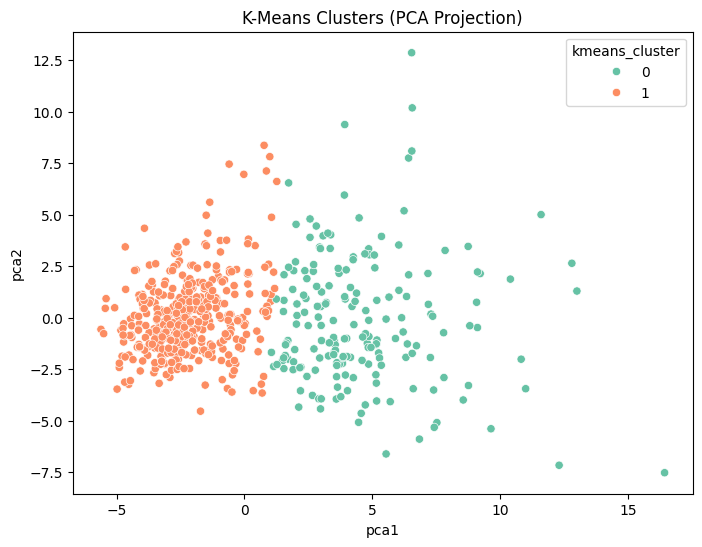

In [ ]:
#creating PCA for visualisation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

data['pca1'] = X_pca[:, 0]
data['pca2'] = X_pca[:, 1]

#Plotting clusters
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='pca1',
    y='pca2',
    hue='kmeans_cluster',
    data=data,
    palette='Set2'
)

plt.title("K-Means Clusters (PCA Projection)")
plt.show()


In [ ]:
score_kmeans = silhouette_score(X_scaled, kmeans_labels)
print("K-Means Silhouette Score:", score_kmeans)

K-Means Silhouette Score: 0.34926592114280164


**Using DBSCAN**

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

# Preparing data
X_dbscan = data[features]
y_dbscan = data['diagnosis_numeric']

# Scaling the data
scaler_db = StandardScaler()
X_dbscan_scaled = scaler_db.fit_transform(X_dbscan)

In [ ]:
#Clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_dbscan_scaled)

#Evaluating the DBSCAN
print("Clusters:", len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0))
print("Noise:", list(dbscan_labels).count(-1))
print("Labels:", np.unique(dbscan_labels))

print("ARI:", adjusted_rand_score(y_dbscan, dbscan_labels))

Clusters: 6
Noise: 480
Labels: [-1  0  1  2  3  4  5]
ARI: -0.057264083556222624


In [ ]:
#Using PCA for visualisation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_dbscan_scaled)

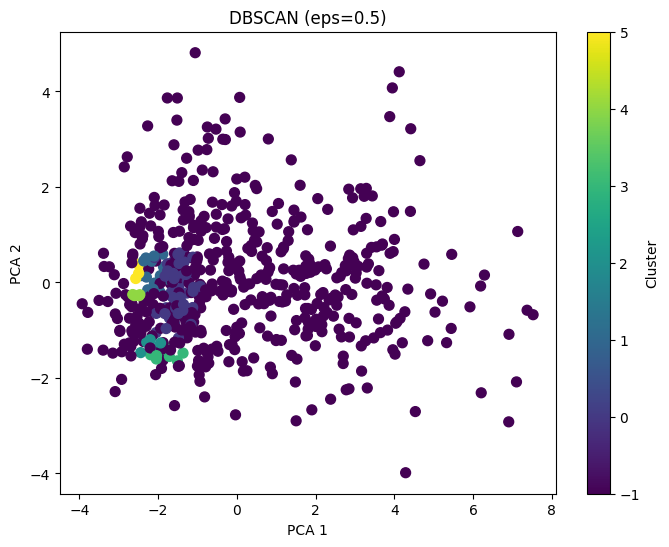

In [ ]:
#Ploting the graph
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='viridis', s=50)

plt.title("DBSCAN (eps=0.5)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(label="Cluster")
plt.show()

In [ ]:
#Tuning the parameters for a better visualisation
for eps in [0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5]:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X_dbscan_scaled)

    print(f"\nEPS = {eps}")
    print("Clusters:", len(set(labels)) - (1 if -1 in labels else 0))
    print("Noise:", list(labels).count(-1))


EPS = 0.6
Clusters: 4
Noise: 377

EPS = 0.7
Clusters: 6
Noise: 303

EPS = 0.8
Clusters: 5
Noise: 235

EPS = 0.9
Clusters: 1
Noise: 182

EPS = 1.0
Clusters: 2
Noise: 130

EPS = 1.1
Clusters: 1
Noise: 97

EPS = 1.2
Clusters: 1
Noise: 75

EPS = 1.3
Clusters: 1
Noise: 54

EPS = 1.4
Clusters: 1
Noise: 43

EPS = 1.5
Clusters: 1
Noise: 36


In [ ]:
dbscan_final = DBSCAN(eps=1.0, min_samples=5)
dbscan_labels_final = dbscan_final.fit_predict(X_dbscan_scaled)

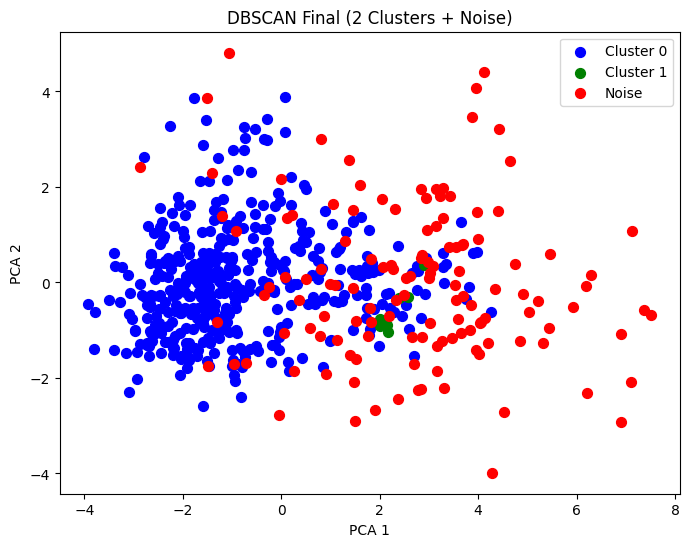

In [ ]:
import matplotlib.pyplot as plt

labels = dbscan_labels_final

# Masks
noise = labels == -1
cluster0 = labels == 0
cluster1 = labels == 1

plt.figure(figsize=(8,6))

# Cluster 0
plt.scatter(
    X_pca[cluster0, 0],
    X_pca[cluster0, 1],
    color='blue',
    s=50,
    label='Cluster 0'
)

# Cluster 1
plt.scatter(
    X_pca[cluster1, 0],
    X_pca[cluster1, 1],
    color='green',
    s=50,
    label='Cluster 1'
)

# Noise
plt.scatter(
    X_pca[noise, 0],
    X_pca[noise, 1],
    color='red',
    s=50,
    label='Noise'
)

plt.legend()
plt.title("DBSCAN Final (2 Clusters + Noise)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [ ]:
# Remove noise (-1)
mask = dbscan_labels_final != -1
X_no_noise = X_dbscan_scaled[mask]
labels_no_noise = dbscan_labels_final[mask]

# Silhouette Score
score = silhouette_score(X_no_noise, labels_no_noise)
print("Silhouette Score:", score)

Silhouette Score: 0.263400540690341
